# Data Analysis for PAPI detection and classification dataset

## Imports

In [43]:
# Imports
import pandas as pd
import os
import shutil
import exifread
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import re
import struct

## File path sorting/matching

In [11]:
# Defining paths for data files
data_master_path = "../../Data/PROJECT1-PAPI/"
data_files = os.listdir(data_master_path)

In [12]:
print("Data files available:")
for file in data_files:
    print(f" - {file}")

Data files available:
 - DJI_202604281910_010_UgCS
 - DJI_202604281946_011_700
 - DJI_202604281946_012_600
 - DJI_202604281946_013_800
 - DJI_202604281946_014_1000
 - DJI_202604290007_019_300mRwy06night
 - DJI_202604290007_020_300mrway06nightdown
 - DJI_202604290007_021_400mrwy06night
 - DJI_202604290007_022_400mrwy06dwnnighf
 - DJI_202604290007_023_500mrwy06night
 - DJI_202604291300_031_day2700mup
 - DJI_202604291300_032_day2700mdwnzoom
 - DJI_202604291357_034_600day2up
 - DJI_202604291550_035_UgCS-vertical600mEDNYPAPIHowest
 - DJI_202604291550_036_400mday2up
 - DJI_202604291738_037_500mday2v2up
 - DJI_202604291738_038_500day2v2dwnzoom
 - DJI_202604291738_039_400mday2up
 - DJI_202604291738_040_400day2dwnleftoffset
 - DJI_202604291738_041_300mday2up
 - DJI_202604291738_042_300mday2dwntiltedzoom
 - PAPI_Coords_Fred_DE.xlsx


In [13]:
# Load excel file into dataframe
excel_path = os.path.join(data_master_path, "PAPI_Coords_Fred_DE.xlsx")
PAPI_06_df = pd.read_excel(excel_path, header=1, nrows=4)
PAPI_06_df.head(4)

,Bezeichnung,Punktnummer,longitude,latitude
0,PAPI 06,1,9.504007,47.668810
1,PAPI 06,2,9.503948,47.668881
2,PAPI 06,3,9.503888,47.668951
3,PAPI 06,4,9.503828,47.669021


In [14]:
PAPI_24_df = pd.read_excel(excel_path, header=9, nrows=4)
PAPI_24_df.head(4)

,Bezeichnung,Punktnummer,longitude,latitude
0,PAPI 24,1,9.518154,47.673521
1,PAPI 24,2,9.518214,47.673450
2,PAPI 24,3,9.518274,47.673380
3,PAPI 24,4,9.518333,47.673309


In [15]:
# Remove excel file from data_files
data_files.remove("PAPI_Coords_Fred_DE.xlsx")

In [16]:
# Split folders based on name to new folders matching the PAPI lights in the image
PAPI_06_data = []
PAPI_24_data = []
for filename in data_files:
    if "y06" in filename:
        PAPI_06_data.append(filename)
    else:
        PAPI_24_data.append(filename)

In [17]:
print(f"PAPI 06 datafiles: {PAPI_06_data}")
print(f"PAPI 24 datafiles: {PAPI_24_data}")

PAPI 06 datafiles: ['DJI_202604290007_019_300mRwy06night', 'DJI_202604290007_020_300mrway06nightdown', 'DJI_202604290007_021_400mrwy06night', 'DJI_202604290007_022_400mrwy06dwnnighf', 'DJI_202604290007_023_500mrwy06night']
PAPI 24 datafiles: ['DJI_202604281910_010_UgCS', 'DJI_202604281946_011_700', 'DJI_202604281946_012_600', 'DJI_202604281946_013_800', 'DJI_202604281946_014_1000', 'DJI_202604291300_031_day2700mup', 'DJI_202604291300_032_day2700mdwnzoom', 'DJI_202604291357_034_600day2up', 'DJI_202604291550_035_UgCS-vertical600mEDNYPAPIHowest', 'DJI_202604291550_036_400mday2up', 'DJI_202604291738_037_500mday2v2up', 'DJI_202604291738_038_500day2v2dwnzoom', 'DJI_202604291738_039_400mday2up', 'DJI_202604291738_040_400day2dwnleftoffset', 'DJI_202604291738_041_300mday2up', 'DJI_202604291738_042_300mday2dwntiltedzoom']


In [10]:
dest_root_06 = "./dataset/PAPI_06"
os.makedirs(dest_root_06, exist_ok=True)

for file_path in PAPI_06_data:
    src = os.path.join(data_master_path, file_path)
    dst = os.path.join(dest_root_06, os.path.basename(file_path))
    
    shutil.copytree(src, dst, dirs_exist_ok=True)

KeyboardInterrupt: 

In [15]:
dest_root_24 = "./dataset/PAPI_24"
os.makedirs(dest_root_24, exist_ok=True)

for file_path in PAPI_24_data:
    src = os.path.join(data_master_path, file_path)
    dst = os.path.join(dest_root_24, os.path.basename(file_path))
    
    shutil.copytree(src, dst, dirs_exist_ok=True)

## Metadata analysis

In [18]:
img_path = "dataset\PAPI_06\DJI_202604290007_019_300mRwy06night\DJI_20260429002101_0001_V.JPG"
def read_all_metadata(image_path):
    with open(image_path, "rb") as f:
        tags = exifread.process_file(f, details=True)

    for tag in tags:
        print(f"{tag}: {tags[tag]}")
read_all_metadata(img_path)

Image ImageDescription: default
Image Make: DJI
Image Model: M4E
Image Orientation: Horizontal (normal)
Image XResolution: 72
Image YResolution: 72
Image ResolutionUnit: Pixels/Inch
Image Software: 10.00.14.82
Image DateTime: 2026:04:29 00:21:01
Image YCbCrPositioning: Co-sited
Image ExifOffset: 260
GPS GPSVersionID: [2, 3, 0, 0]
GPS GPSLatitudeRef: N
GPS GPSLatitude: [47, 40, 29479/10000]
GPS GPSLongitudeRef: E
GPS GPSLongitude: [9, 30, 3263/2000]
GPS GPSAltitudeRef: 0
GPS GPSAltitude: 465147/1000
GPS GPSStatus: A
GPS GPSMapDatum: WGS-84
Image GPSInfo: 758
Image XPComment: [48, 0, 46, 0, 57, 0, 46, 0, 49, 0, 52, 0, 50, 0, 0, 0, 0, 0, 0, 0, ... ]
Image XPKeywords: [115, 0, 105, 0, 110, 0, 103, 0, 108, 0, 101, 0]
Thumbnail Compression: JPEG
Thumbnail XResolution: 72
Thumbnail YResolution: 72
Thumbnail ResolutionUnit: Pixels/Inch
Thumbnail JPEGInterchangeFormat: 6808
Thumbnail JPEGInterchangeFormatLength: 1925
EXIF ExposureTime: 1/80
EXIF FNumber: 14/5
EXIF ExposureProgram: Manual
EXIF I

## Extracting metadata to dataframe

In [19]:
def parse_ifd_ratio(value):
    """
    Converts exifread IfdTag (DJI-safe) to float
    """
    try:
        v = value.values

        # Case: single Ratio like 465147/1000
        if hasattr(v, "num") and hasattr(v, "den"):
            return float(v.num) / float(v.den)

        # Case: list containing Ratio
        if isinstance(v, (list, tuple)):
            first = v[0]

            if hasattr(first, "num") and hasattr(first, "den"):
                return float(first.num) / float(first.den)

            return float(first)

        return float(v)

    except Exception:
        return None

In [20]:
def get_gps_exifread(image_path):
    with open(image_path, 'rb') as f:
        tags = exifread.process_file(f, details=False)

    lat = lon = alt = None

    try:
        lat_ref = tags.get("GPS GPSLatitudeRef")
        lat_val = tags.get("GPS GPSLatitude")
        lon_ref = tags.get("GPS GPSLongitudeRef")
        lon_val = tags.get("GPS GPSLongitude")

        alt_ref = tags.get("GPS GPSAltitudeRef")
        alt_val = tags.get("GPS GPSAltitude")

        # ---- LAT/LON ----
        def to_deg(v):
            d, m, s = v.values
            return (
                float(d.num / d.den) +
                float(m.num / m.den) / 60 +
                float(s.num / s.den) / 3600
            )

        if lat_val and lon_val:
            lat = to_deg(lat_val)
            lon = to_deg(lon_val)

            if lat_ref.values != "N":
                lat = -lat
            if lon_ref.values != "E":
                lon = -lon

        # ---- ALTITUDE (NOW FIXED) ----
        if alt_val:
            alt = parse_ifd_ratio(alt_val)

            if alt_ref.values == 1:
                alt = -alt

    except Exception as e:
        print("ERROR:", e)

    return lat, lon, alt

In [21]:
rows = []

for root, _, files in os.walk("./dataset/PAPI_06"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg")):
            path = os.path.join(root, file)

            lat, lon, alt = get_gps_exifread(path)

            rows.append({
                "file": file,
                "path": path,
                "latitude": lat,
                "longitude": lon,
                "altitude": alt
            })

df_PAPI_06_metadata = pd.DataFrame(rows)
df_PAPI_06_metadata.head()

,file,path,latitude,longitude,altitude
0,DJI_20260429002101_0001_V.JPG,./dataset/PAPI_06\DJI_202604290007_019_300mRwy...,47.667486,9.500453,465.147
1,DJI_20260429002102_0003_V.JPG,./dataset/PAPI_06\DJI_202604290007_019_300mRwy...,47.667485,9.500453,465.143
2,DJI_20260429002102_0004_V.JPG,./dataset/PAPI_06\DJI_202604290007_019_300mRwy...,47.667486,9.500453,465.141
3,DJI_20260429002103_0005_V.JPG,./dataset/PAPI_06\DJI_202604290007_019_300mRwy...,47.667486,9.500453,465.141
4,DJI_20260429002104_0006_V.JPG,./dataset/PAPI_06\DJI_202604290007_019_300mRwy...,47.667486,9.500453,465.139


In [22]:
rows = []

for root, _, files in os.walk("./dataset/PAPI_24"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg")):
            path = os.path.join(root, file)

            lat, lon, alt = get_gps_exifread(path)

            rows.append({
                "file": file,
                "path": path,
                "latitude": lat,
                "longitude": lon,
                "altitude": alt
            })

df_PAPI_24_metadata = pd.DataFrame(rows)
df_PAPI_24_metadata.head()

,file,path,latitude,longitude,altitude
0,DJI_20260428192656_0001_V.JPG,./dataset/PAPI_24\DJI_202604281910_010_UgCS\DJ...,47.675202,9.522888,468.034
1,DJI_20260428192657_0003_V.JPG,./dataset/PAPI_24\DJI_202604281910_010_UgCS\DJ...,47.675202,9.522888,468.035
2,DJI_20260428192657_0004_V.JPG,./dataset/PAPI_24\DJI_202604281910_010_UgCS\DJ...,47.675202,9.522888,468.054
3,DJI_20260428192658_0005_V.JPG,./dataset/PAPI_24\DJI_202604281910_010_UgCS\DJ...,47.675202,9.522888,468.094
4,DJI_20260428192658_0006_V.JPG,./dataset/PAPI_24\DJI_202604281910_010_UgCS\DJ...,47.675202,9.522888,468.145


In [23]:
PAPI_06_Height = min(df_PAPI_06_metadata["altitude"].values)
print(f"PAPI_06 Approximate floor height: {PAPI_06_Height}")
PAPI_24_Height = min(df_PAPI_24_metadata["altitude"].values)
print(f"PAPI_24 Approximate floor height: {PAPI_24_Height}")

PAPI_06 Approximate floor height: 464.988
PAPI_24 Approximate floor height: 467.609


In [24]:
# PAPI_06_df["altitude"] = PAPI_06_Height
# PAPI_24_df["altitude"] = PAPI_24_Height
PAPI_06_df["altitude"] = 461.37
PAPI_24_df["altitude"] = 461.37
PAPI_06_df.head()

,Bezeichnung,Punktnummer,longitude,latitude,altitude
0,PAPI 06,1,9.504007,47.668810,461.37
1,PAPI 06,2,9.503948,47.668881,461.37
2,PAPI 06,3,9.503888,47.668951,461.37
3,PAPI 06,4,9.503828,47.669021,461.37


In [25]:
PAPI_24_df.head()

,Bezeichnung,Punktnummer,longitude,latitude,altitude
0,PAPI 24,1,9.518154,47.673521,461.37
1,PAPI 24,2,9.518214,47.673450,461.37
2,PAPI 24,3,9.518274,47.673380,461.37
3,PAPI 24,4,9.518333,47.673309,461.37


## Calculate angle to the PAPI lights

In [26]:
# Runway Vector Thresholds
T1 = (47.675307, 9.521750, 461.37)
T2 = (47.667610, 9.501891, 461.37)

In [27]:
# WGS84 constants
a = 6378137.0              # semi-major axis
f = 1 / 298.257223563
e2 = f * (2 - f)


def lla_to_ecef(lat, lon, alt):
    """Convert lat/lon/alt (deg, deg, m) to ECEF"""
    lat = np.radians(lat)
    lon = np.radians(lon)

    N = a / np.sqrt(1 - e2 * np.sin(lat)**2)

    x = (N + alt) * np.cos(lat) * np.cos(lon)
    y = (N + alt) * np.cos(lat) * np.sin(lon)
    # include sin(lat) for proper ECEF Z coordinate
    z = (N * (1 - e2) + alt) * np.sin(lat)

    return np.array([x, y, z])


def ecef_to_enu(x, y, z, ref_lat, ref_lon, ref_alt):
    """Convert ECEF to ENU relative to reference LLA"""
    ref_lat = np.radians(ref_lat)
    ref_lon = np.radians(ref_lon)

    # reference point in ECEF
    x0, y0, z0 = lla_to_ecef(ref_lat * 180/np.pi, ref_lon * 180/np.pi, ref_alt)

    dx, dy, dz = x - x0, y - y0, z - z0

    slat = np.sin(ref_lat)
    clat = np.cos(ref_lat)
    slon = np.sin(ref_lon)
    clon = np.cos(ref_lon)

    # rotation matrix
    t = np.array([
        [-slon,        clon,       0],
        [-slat*clon, -slat*slon,   clat],
        [ clat*clon,  clat*slon,   slat]
    ])

    enu = t @ np.array([dx, dy, dz])
    return enu  # East, North, Up

In [28]:
T1 = (47.675307, 9.521750, 461.37)
T2 = (47.667610, 9.501891, 461.37)

# Convert endpoints
T1_ecef = lla_to_ecef(*T1)
T2_ecef = lla_to_ecef(*T2)

# Use T1 as ENU reference
runway_vec_enu = ecef_to_enu(*T2_ecef, *T1)

# horizontal projection
runway_vec_enu[2] = 0
runway_vec_enu = runway_vec_enu / np.linalg.norm(runway_vec_enu)

In [29]:
def horizontal_angle(v1, v2):
    """Angle between two vectors in horizontal plane"""
    v1 = np.array([v1[0], v1[1], 0])
    v2 = np.array([v2[0], v2[1], 0])

    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)

    dot = np.clip(np.dot(v1, v2), -1.0, 1.0)
    # return degrees for easier interpretation
    return np.degrees(np.arccos(dot))

In [30]:
def compute_enu_df(df, ref_point):
    enu_list = []

    for _, row in df.iterrows():
        ecef = lla_to_ecef(row["latitude"], row["longitude"], row["altitude"])
        enu = ecef_to_enu(*ecef, *ref_point)
        enu_list.append(enu)

    df = df.copy()
    df[["E", "N", "U"]] = np.array(enu_list)
    return df

In [31]:
ref = T1

df_drone_24 = compute_enu_df(df_PAPI_24_metadata, ref)
df_lights_24 = compute_enu_df(PAPI_24_df, ref)

df_drone_06 = compute_enu_df(df_PAPI_06_metadata, ref)
df_lights_06 = compute_enu_df(PAPI_06_df, ref)

In [32]:
def compute_angles(drone_df, lights_df, runway_vec):
    results = []

    for i, drone in drone_df.iterrows():
        d_vec = np.array([drone["E"], drone["N"], 0])

        for j, light in lights_df.iterrows():
            l_vec = np.array([light["E"], light["N"], 0])

            rel = l_vec - d_vec

            # angle is returned in degrees
            angle = horizontal_angle(runway_vec, rel)

            results.append({
                "drone_idx": i,
                "light_idx": j,
                "angle_deg": angle
            })

    return pd.DataFrame(results)

In [33]:
angles_24 = compute_angles(df_drone_24, df_lights_24, runway_vec_enu)
angles_06 = compute_angles(df_drone_06, df_lights_06, runway_vec_enu)

In [34]:
angles_24["runway"] = "24"
angles_06["runway"] = "06"

df_angles = pd.concat([angles_24, angles_06], ignore_index=True) 

Runway 24 angle_deg min/max: 0.0014687237035258868 3.254827047711945
Runway 06 angle_deg min/max (before flip): 175.8685099030115 179.7328523643927
Runway 06 angle_deg min/max (after flip): 0.2671476356073015 4.1314900969885


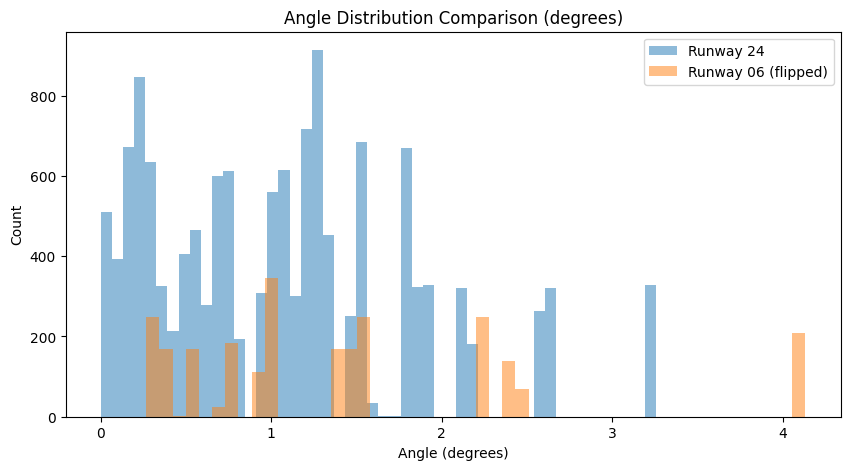

In [47]:
plt.figure(figsize=(10,5))

# use degrees (angle_deg) — convert/runway 06 to same reference by 180 - angle
angles_24 = df_angles[df_angles["runway"]=="24"]["angle_deg"]
angles_06 = df_angles[df_angles["runway"]=="06"]["angle_deg"]
angles_06_flipped = 180.0 - angles_06

print("Runway 24 angle_deg min/max:", angles_24.min(), angles_24.max())
print("Runway 06 angle_deg min/max (before flip):", angles_06.min(), angles_06.max())
print("Runway 06 angle_deg min/max (after flip):", angles_06_flipped.min(), angles_06_flipped.max())

plt.hist(
    angles_24,
    bins=50,
    alpha=0.5,
    label="Runway 24"
)

plt.hist(
    angles_06_flipped,
    bins=50,
    alpha=0.5,
    label="Runway 06 (flipped)"
)

plt.legend()
plt.title("Angle Distribution Comparison (degrees)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")

plt.show()

## Full Dataset folder merging and analysis

In [36]:
# =========================================================
# INPUT / OUTPUT
# =========================================================

SOURCE_ROOT = "PAPI_Full"
OUTPUT_ROOT = "PAPI_Merged"

OUTPUT_IMAGES = os.path.join(OUTPUT_ROOT, "images")
OUTPUT_LABELS = os.path.join(OUTPUT_ROOT, "labels")

os.makedirs(OUTPUT_IMAGES, exist_ok=True)
os.makedirs(OUTPUT_LABELS, exist_ok=True)

# =========================================================
# VALID IMAGE EXTENSIONS
# =========================================================

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

# =========================================================
# COUNTERS
# =========================================================

image_count = 0
label_count = 0

# =========================================================
# WALK THROUGH ENTIRE DATASET
# =========================================================

for root, dirs, files in os.walk(SOURCE_ROOT):

    # -----------------------------------------------------
    # MERGE IMAGES
    # -----------------------------------------------------

    if os.path.basename(root).lower() == "images":

        for file in files:

            if not file.lower().endswith(IMAGE_EXTENSIONS):
                continue

            src_path = os.path.join(root, file)

            # Create unique filename
            parent_folder = os.path.basename(os.path.dirname(root))
            new_name = f"{parent_folder}_{file}"

            dst_path = os.path.join(OUTPUT_IMAGES, new_name)

            shutil.copy2(src_path, dst_path)

            image_count += 1

    # -----------------------------------------------------
    # MERGE LABELS
    # -----------------------------------------------------

    if os.path.basename(root).lower() == "labels":

        for file in files:

            if not file.lower().endswith(".txt"):
                continue

            src_path = os.path.join(root, file)

            # Create matching unique filename
            parent_folder = os.path.basename(os.path.dirname(root))
            new_name = f"{parent_folder}_{file}"

            dst_path = os.path.join(OUTPUT_LABELS, new_name)

            shutil.copy2(src_path, dst_path)

            label_count += 1

# =========================================================
# DONE
# =========================================================

print(f"Copied {image_count} images")
print(f"Copied {label_count} labels")
print("Dataset merge complete.")

KeyboardInterrupt: 

## Splitting into training, testing and validation folders

In [5]:
# =========================================================
# SETTINGS
# =========================================================

SOURCE_DATASET = "PAPI_Merged"

IMAGES_DIR = os.path.join(SOURCE_DATASET, "images")
LABELS_DIR = os.path.join(SOURCE_DATASET, "labels")

OUTPUT_DATASET = "PAPI_Split"

TRAIN_RATIO = 0.70
VALID_RATIO = 0.20
TEST_RATIO  = 0.10

RANDOM_SEED = 42

# =========================================================
# CREATE OUTPUT STRUCTURE
# =========================================================

splits = ["train", "valid", "test"]

for split in splits:

    os.makedirs(
        os.path.join(OUTPUT_DATASET, split, "images"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(OUTPUT_DATASET, split, "labels"),
        exist_ok=True
    )

# =========================================================
# GET ALL IMAGES
# =========================================================

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

all_images = [
    f for f in os.listdir(IMAGES_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

# Shuffle reproducibly
random.seed(RANDOM_SEED)
random.shuffle(all_images)

# =========================================================
# CALCULATE SPLITS
# =========================================================

total = len(all_images)

train_end = int(total * TRAIN_RATIO)
valid_end = train_end + int(total * VALID_RATIO)

train_files = all_images[:train_end]
valid_files = all_images[train_end:valid_end]
test_files  = all_images[valid_end:]

print(f"Total images: {total}")
print(f"Train: {len(train_files)}")
print(f"Valid: {len(valid_files)}")
print(f"Test : {len(test_files)}")

# =========================================================
# COPY FILES
# =========================================================

def copy_split(files, split_name):

    for image_file in files:

        image_src = os.path.join(IMAGES_DIR, image_file)

        label_file = image_file.rsplit(".", 1)[0] + ".txt"
        label_src = os.path.join(LABELS_DIR, label_file)

        image_dst = os.path.join(
            OUTPUT_DATASET,
            split_name,
            "images",
            image_file
        )

        label_dst = os.path.join(
            OUTPUT_DATASET,
            split_name,
            "labels",
            label_file
        )

        # Copy image
        shutil.copy2(image_src, image_dst)

        # Copy label if exists
        if os.path.exists(label_src):
            shutil.copy2(label_src, label_dst)

# =========================================================
# EXECUTE SPLITS
# =========================================================

copy_split(train_files, "train")
copy_split(valid_files, "valid")
copy_split(test_files, "test")

print("Dataset split complete.")

Total images: 3194
Train: 2235
Valid: 638
Test : 321
Dataset split complete.


## Inspecting .MRK contents

In [3]:
file_path = "dataset\PAPI_06\DJI_202604290007_019_300mRwy06night\DJI_20260429002102_0002_D.MRK"

In [7]:
def parse_mrk_file(path):
    rows = []

    with open(path, "r", errors="ignore") as f:
        for line in f:
            # skip header lines
            if "Lat" not in line or "Lon" not in line:
                continue

            try:
                # time (second column)
                time_match = re.search(r"\s(\d+\.\d+)\s\[\d+\]", line)
                if not time_match:
                    continue
                timestamp = float(time_match.group(1))

                # lat/lon/height
                lat_match = re.search(r"(\d+\.\d+),Lat", line)
                lon_match = re.search(r"(\d+\.\d+),Lon", line)
                alt_match = re.search(r"(\d+\.\d+),Ellh", line)

                if not (lat_match and lon_match and alt_match):
                    continue

                lat = float(lat_match.group(1))
                lon = float(lon_match.group(1))
                ellh = float(alt_match.group(1))

                # quality (last number before Q)
                q_match = re.search(r"(\d+),Q", line)
                quality = int(q_match.group(1)) if q_match else None

                rows.append({
                    "time": timestamp,
                    "lat": lat,
                    "lon": lon,
                    "ellh": ellh,
                    "quality": quality
                })

            except Exception:
                continue

    return pd.DataFrame(rows)

In [8]:
df_mrk = parse_mrk_file(file_path)

In [9]:
df_mrk.head()

,time,lat,lon,ellh,quality
0,253280.237956,47.667486,9.500453,465.147,50
1,253280.899105,47.667485,9.500453,465.143,50
2,253281.594059,47.667486,9.500453,465.141,50
3,253282.265328,47.667486,9.500453,465.141,50
4,253282.970827,47.667486,9.500453,465.139,50


In [ ]:
df_mrk["ellh"].values

array([465.147, 465.143, 465.141, 465.141, 465.139, 465.15 , 465.191,
       465.249, 465.311, 465.379, 465.455, 465.544, 465.677, 465.862,
       466.044, 466.235, 466.425, 466.614, 466.801, 467.001, 467.189,
       467.384, 467.575, 467.772, 468.018, 468.271, 468.529, 468.796,
       469.055, 469.298, 469.547, 469.808, 470.069, 470.326, 470.568,
       470.821, 471.051, 471.271, 471.496, 471.716, 471.933, 472.153,
       472.322, 472.493, 472.647, 472.803, 472.969, 473.115, 473.276,
       473.433, 473.573, 473.723, 473.866, 474.017, 474.157, 474.299,
       474.427, 474.572, 474.697, 474.827, 474.949, 475.061, 475.174,
       475.298, 475.429, 475.548])

In [39]:
df_PAPI_06_metadata["altitude"].values[:66]

array([465.147, 465.143, 465.141, 465.141, 465.139, 465.15 , 465.191,
       465.249, 465.311, 465.379, 465.455, 465.544, 465.677, 465.862,
       466.044, 466.235, 466.425, 466.614, 466.801, 467.001, 467.189,
       467.384, 467.575, 467.772, 468.018, 468.271, 468.529, 468.796,
       469.055, 469.298, 469.547, 469.808, 470.069, 470.326, 470.568,
       470.821, 471.051, 471.271, 471.496, 471.716, 471.933, 472.153,
       472.322, 472.493, 472.647, 472.804, 472.969, 473.115, 473.276,
       473.433, 473.573, 473.723, 473.866, 474.017, 474.157, 474.299,
       474.428, 474.572, 474.697, 474.827, 474.949, 475.061, 475.174,
       475.298, 475.429, 475.548])

In [40]:
df_mrk["ellh"].values - df_PAPI_06_metadata["altitude"].values[:66]

array([ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   , -0.001,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
       -0.001,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ])

.mrk and image metadata altitude are almost perfectly equal

## Decoding .RTK file

In [41]:
rtk_file_path = "dataset\PAPI_06\DJI_202604290007_019_300mRwy06night\DJI_20260429002102_0002_D.RTK"

In [46]:
with open(rtk_file_path, "rb") as f:
    data = f.read()

    # scan for float64 values
    for i in range(0, len(data)-8, 8):
        val = struct.unpack("<d", data[i:i+8])[0]

        if -180 < val < 180:   # possible lat/lon
            print("deg-like:", i, val)

        if 100 < val < 1000:   # possible altitude
            print("alt-like:", i, val)

deg-like: 0 5.113377031512021e-283
deg-like: 24 3.204706268546035e-71
deg-like: 48 1.850649181511411e-307
deg-like: 56 1.7047971e-316
deg-like: 72 -3.2688442215660987e-57
deg-like: 80 -5.701956341601513e-32
deg-like: 96 1.4040199914180895e-17
deg-like: 104 2.5626978949994685e-88
deg-like: 112 -6.455814049043367e-76
deg-like: 120 2.4084753692612977e-47
deg-like: 136 6.916043985738085e-279
deg-like: 192 -5.776622002767454e-275
deg-like: 200 2.3546482399084698e-107
deg-like: 208 6.349392966039354e-193
deg-like: 224 6.720380504263908e-298
deg-like: 232 -4.162719374123719e-90
deg-like: 256 2.9801988435649397e-289
deg-like: 264 2.87034527747429e-306
deg-like: 272 -4.764391238139945e-125
deg-like: 280 -3.0442267789766017e-52
deg-like: 288 7.854408575364155e-94
deg-like: 296 4.042420559654017e-258
deg-like: 304 2.2691520535121048e-225
deg-like: 320 -2.729933211359197e-176
deg-like: 336 1.635153178669979e-255
deg-like: 352 3.276656427271911e-257
deg-like: 400 -4.389355720106714e-272
deg-like: 4